<a href="https://colab.research.google.com/github/jaehyeon0420/agent_tutorial/blob/master/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture --no-stderr
!sudo apt install tesseract-ocr
!sudo apt install libtesseract-dev
!sudo apt-get install poppler-utils

In [2]:
%%capture --no-stderr
!pip install -U "unstructured[all-docs]" lxml pillow==9.5.0 pdf2image==1.16.3 layoutparser[layoutmodels,tesseract]==0.3.4

In [1]:
import nltk

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [3]:
import os
import base64
from IPython.display import display, HTML
from unstructured.partition.pdf import partition_pdf

In [ ]:
# 파일 경로 설정
fpath = '/content/'
fname = "2026_경제_전망.pdf"

# PDF에서 요소 추출
raw_pdf_elements = partition_pdf(
    filename=os.path.join(fpath, fname),
    extract_images_in_pdf=True, # 이미지 추출
    skip_infer_table_types=False, # False로 하면 테이블을 추출
    chunking_strategy="by_title", # 텍스트를 섹션 경계에 따라서 청킹
    max_characters=2000, # 각 청킹 별 최대 글자 수
    new_after_n_chars=2000, # 이 숫자를 넘으면 추가로 잘라라
    combine_text_under_n_chars=2000, # 이 크기 이하의 텍스트는 다른 텍스트와 결합하라
    extract_image_block_output_dir=fpath,
)

In [6]:
tables = []
texts = []

for chunk in raw_pdf_elements:
    if "CompositeElement" in str(type(chunk)):  # Check if it's a CompositeElement
        for element in chunk.metadata.orig_elements:  # Iterate through its elements
            if "Table" in str(type(element)):  # Now check for Table type
                tables.append(element)  # Append the table element
        texts.append(chunk)  # Still append the CompositeElement to texts

In [9]:
len(tables)

16

In [15]:
print(str(tables[5]))

213 BIZ / BI / Wet oH] 7] 6~9H, 2 FFX SH AY (Primaries) SH (354) 45 (13) / 51 (20) / 4 SH Get AIS DATA, AAO, SeyAPt, QSpoje | ote (43544) 210 / 206 / 19 ole Bet AIS OPAL, WejsLOF, OJAI S ag ee? BALA (Sats SAL, WES AA) ZA (45441) 20/ 25/5 ARAt BSt TH, O[YAE, GAY, AAO S


In [19]:
print(str(texts[2]))

위험 요인, 1) 트럼프 리스크, 2) 글로벌 AI 투자 붐, 3) 장기금리 상승과 부채 위험

fy SIA}

7H

2026UOIE

• 2026년에도 미국 트럼프는 가장 큰 리스크 – 관세는 뉴 노멀, 그린란드와 이란 등 갈등 심화 (지정학적), 정책 및 정치 리스크, 동맹 리스크 등

• 다만, 11월 미국 중간선거 앞두고 트럼프 리스크는 다소 완화될 전망 – 6~7월 예비선거로 시즌 시작, 낮은 트럼프 지지율은 달러에 약세 요인

• 글로벌 AI 투자 붐은 가장 위험 요인 – 전세계적으로 AI 투자 확대, 과잉 투자 논란은 지속, 한국 반도체 수출 경기에도 부정적 요인

• 장기 금리 상승에 부채 위험 고조 – 일본 등 주요국의 장기 금리 상승, 미국과 일본 등 부채 국가들의 이자 지급 급증, 글로벌 실물경기에 부정적

4

[세계 경제] 트럼프 관세 부과에도 글로벌 경제는 순항 중

▪ 글로벌 경기 사이클을 보여주는 OECD 경기선행지수 순환변동치 (선행경기 사이클)는 14개월 연속 확장 국면

* 미국, 유로 등 선진국의 선행경기는 확장 추세 지속, 중국 등 신흥국 경기선행지표도 완만한 회복

▪ 최근 3개월 미국, 중국 등 주요국의 경제성장률 양호, 2026년 성장률 전망도 상향 조정

* 관세 부과에도 경기확장 배경 - 1) 미국 소비지출 견고 (수요), 2) 글로벌 금리인하 동조 (완화), 3) 글로벌 공급망 변화 (미국-중국)

OECD 글로벌 선행경기 사이클은 14개월 연속 확장 국면

주요국 2026년 경제성장률 전망 상향

a v. So oO a nr = A é~ zm a x a N a y = ~ oF N Ww qc wx oe) a x I I Ss oO a a ue A ro) N uN ge 8s & fB §& co 9s Dn DB WB Sse 40 A OR

a~im Do YnNMimn YM FON SI O)/O Ole ia . ee }FlFir leis} le air KO KI ana Ti VIA Sn 4H Oo CO Nin Gio 

In [32]:
import os
from PIL import Image

# 이미지 디렉토리 경로 (원래대로 복원)
image_path = "/content/"  # ← 이 줄이 핵심입니다. 당신 환경에 맞게 경로 수정하십시오.

# 1. 조건에 맞는 모든 파일 저장할 리스트
all_files = []

# 2. width 50 이하인 파일 저장할 리스트
small_width_files = []

# 3. height 50 이하인 파일 저장할 리스트
small_height_files = []

# 디렉토리 내 파일 순회
for filename in os.listdir(image_path):
    # 파일명이 'figure'로 시작하고 '.jpg'로 끝나는지 확인
    if filename.startswith('figure') and filename.endswith('.jpg'):
        all_files.append(filename)  # all_files에 추가
        try:
            # 이미지 열기
            with Image.open(os.path.join(image_path, filename)) as img:
                width, height = img.size
                # width가 50 이하인 경우 small_width_files에 추가
                if width <= 300:
                    small_width_files.append(filename)
                # height가 50 이하인 경우 small_height_files에 추가
                if height <= 300:
                    small_height_files.append(filename)
        except Exception as e:
            print(f"파일 열기 실패: {filename}, 에러: {e}")

# 문자열 기준 정렬
all_files = sorted(all_files)
small_width_files = sorted(small_width_files)
small_height_files = sorted(small_height_files)
large_width_files = sorted(list(set(all_files) - set(small_width_files)))

# 결과 출력
print(f"모든 'figure*.jpg' 파일 ({len(all_files)}개):")
print(all_files)

print(f"\n가로 50 이하인 파일 ({len(small_width_files)}개):")
print(small_width_files)

print(f"\n세로 50 이하인 파일 ({len(small_height_files)}개):")
print(small_height_files)

모든 'figure*.jpg' 파일 (81개):
['figure-1-1.jpg', 'figure-1-2.jpg', 'figure-1-3.jpg', 'figure-1-4.jpg', 'figure-1-5.jpg', 'figure-1-6.jpg', 'figure-10-11.jpg', 'figure-10-12.jpg', 'figure-11-13.jpg', 'figure-11-14.jpg', 'figure-12-15.jpg', 'figure-12-16.jpg', 'figure-13-17.jpg', 'figure-13-18.jpg', 'figure-14-19.jpg', 'figure-14-20.jpg', 'figure-15-21.jpg', 'figure-16-22.jpg', 'figure-16-23.jpg', 'figure-17-24.jpg', 'figure-21-25.jpg', 'figure-21-26.jpg', 'figure-22-27.jpg', 'figure-22-28.jpg', 'figure-23-29.jpg', 'figure-23-30.jpg', 'figure-24-31.jpg', 'figure-24-32.jpg', 'figure-25-33.jpg', 'figure-25-34.jpg', 'figure-26-35.jpg', 'figure-26-36.jpg', 'figure-27-37.jpg', 'figure-27-38.jpg', 'figure-28-39.jpg', 'figure-28-40.jpg', 'figure-29-41.jpg', 'figure-29-42.jpg', 'figure-30-43.jpg', 'figure-30-44.jpg', 'figure-31-45.jpg', 'figure-31-46.jpg', 'figure-32-47.jpg', 'figure-32-48.jpg', 'figure-33-49.jpg', 'figure-33-50.jpg', 'figure-34-51.jpg', 'figure-34-52.jpg', 'figure-35-53.jpg', 'fig


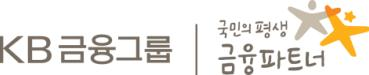
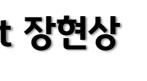
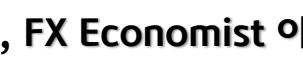
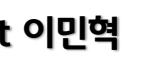
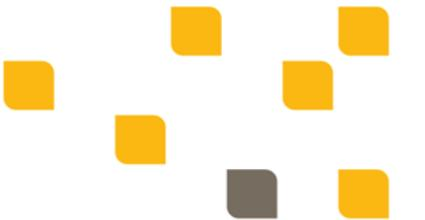
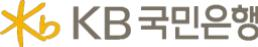
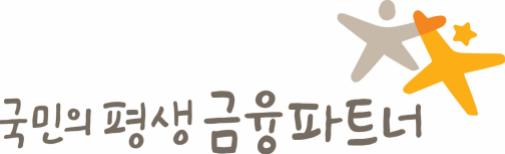
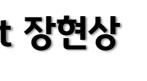
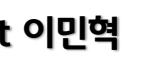
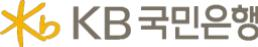

In [33]:
# 현재 디렉토리 파일 목록
small_file_path = [image_path + '/' + file_name for file_name in small_height_files] + [image_path + '/' + file_name for file_name in small_width_files]


# 이미지들을 base64로 인코딩하고 HTML로 묶기
html = "<div style='display: flex; flex-wrap: wrap;'>"
for file_name in small_file_path:
    with open(file_name, "rb") as img_file:
        b64_img = base64.b64encode(img_file.read()).decode('utf-8')
    # object-fit: contain 추가!
    html += f"""
    <div style="flex: none; max-width: 200px; margin-right: 10px; margin-bottom: 10px;">
        <img src="data:image/jpeg;base64,{b64_img}" style="width: 100%; height: auto; display: block; object-fit: contain;">
    </div>
    """
html += "</div>"

display(HTML(html))


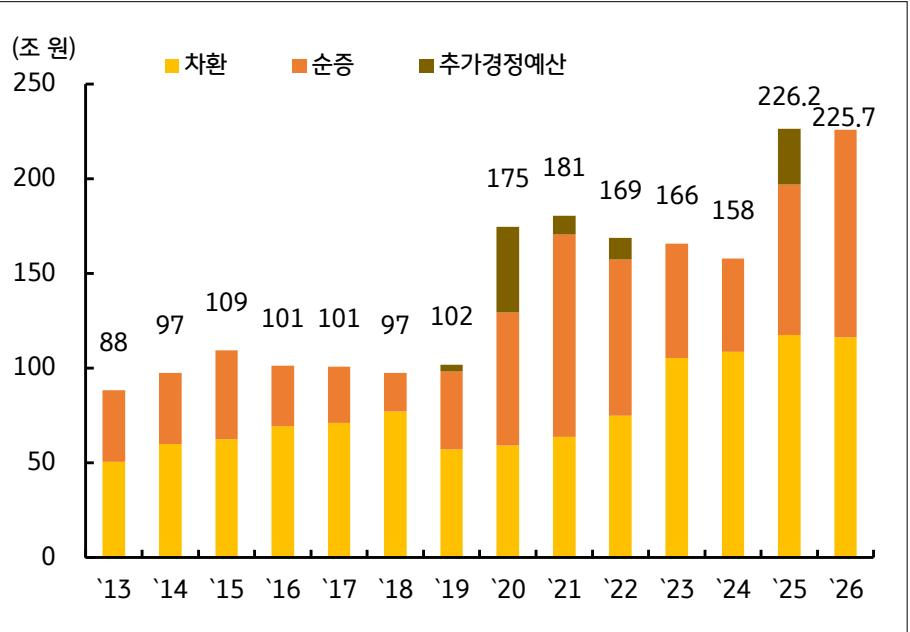
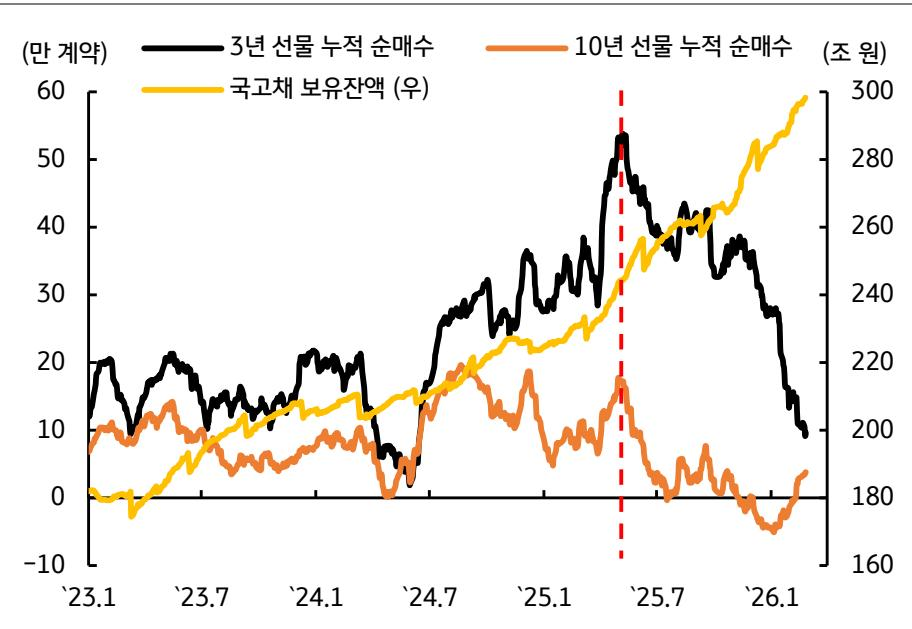
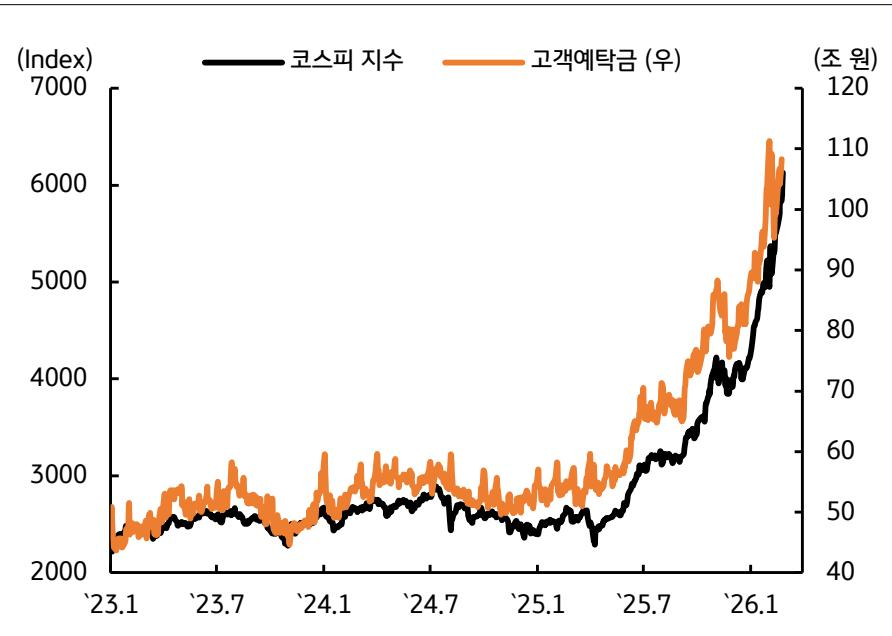
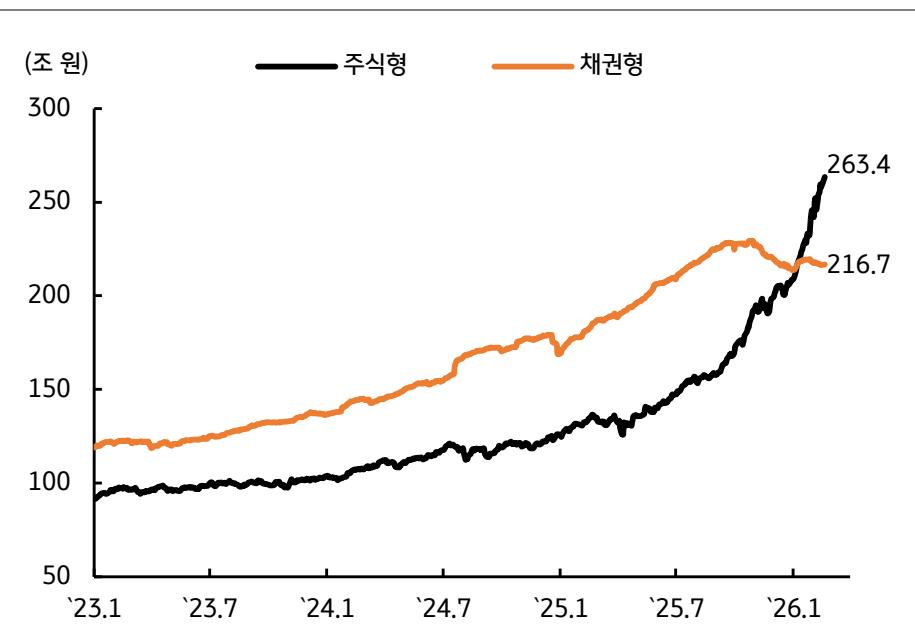
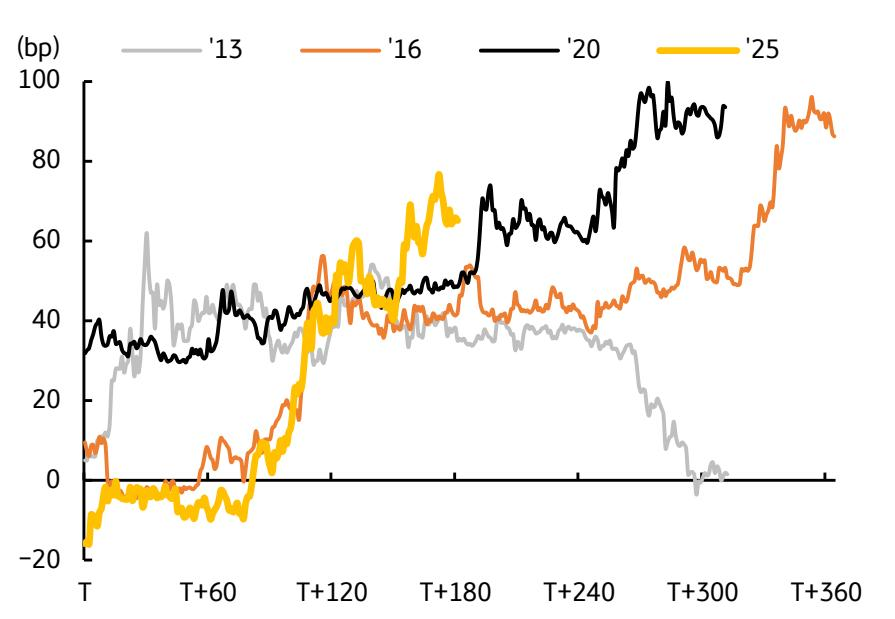
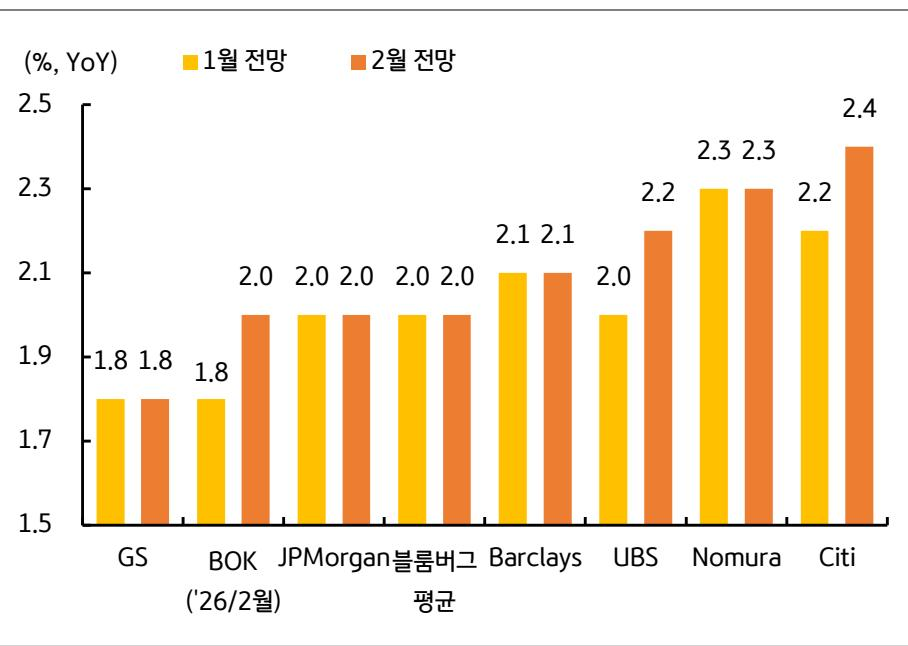
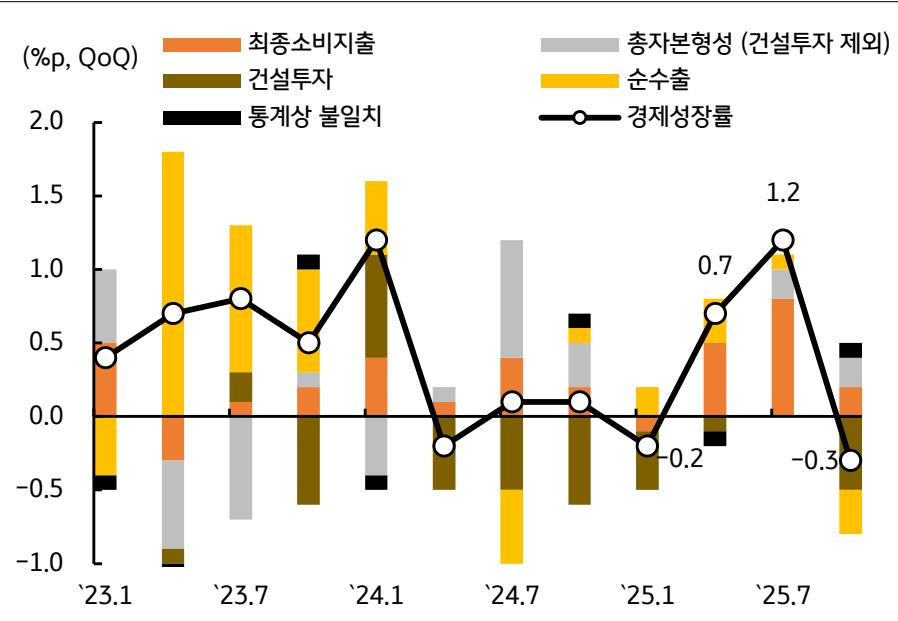
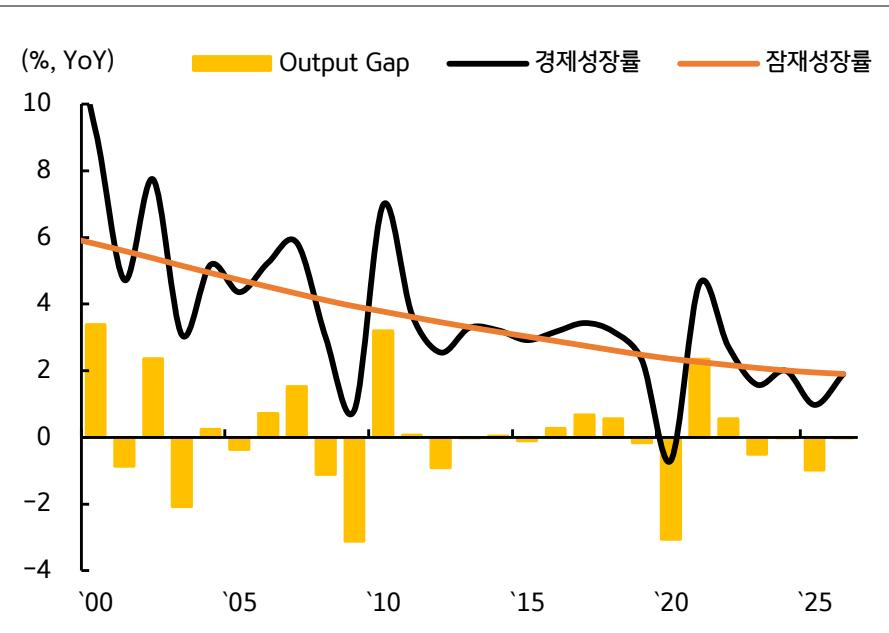
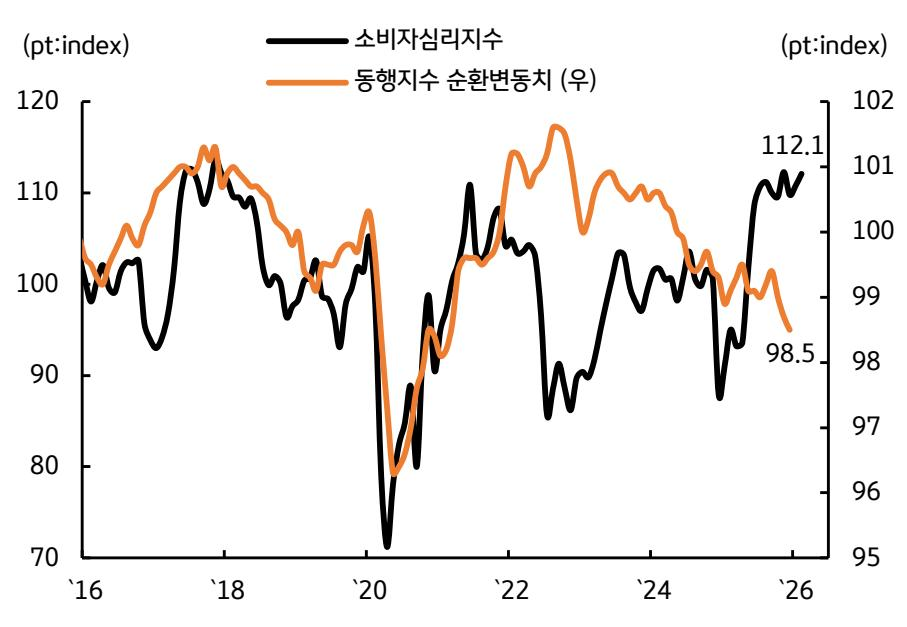
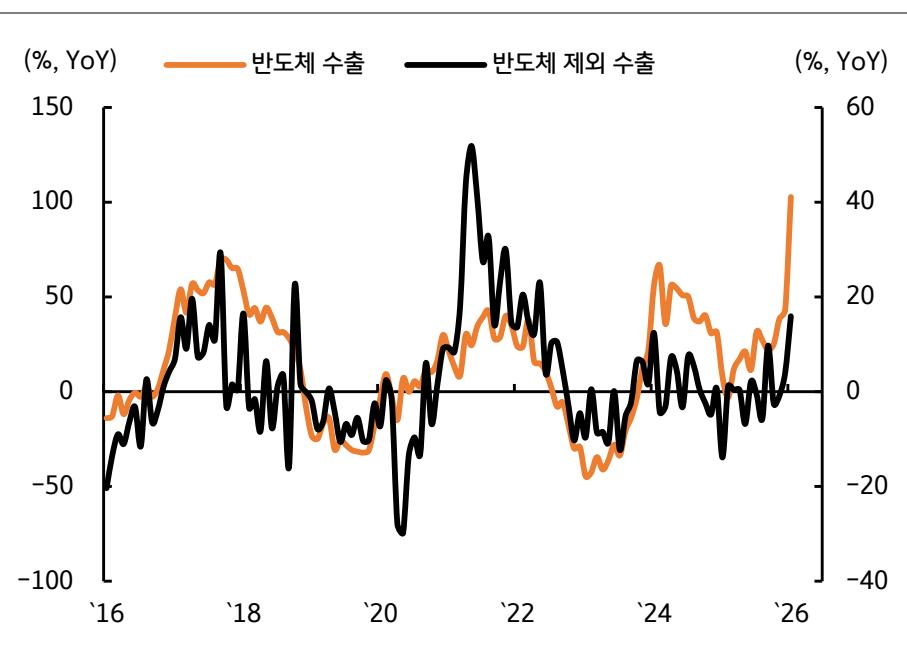
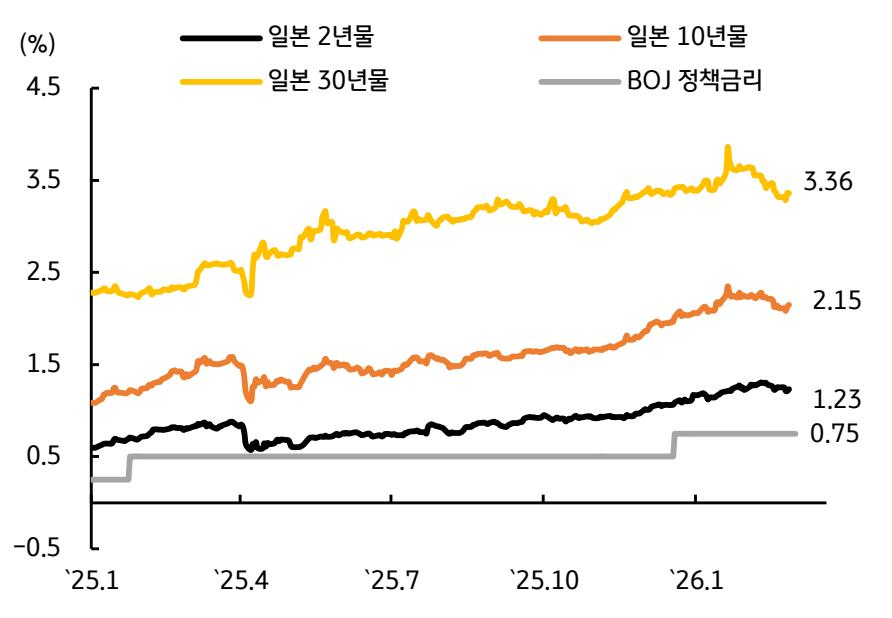
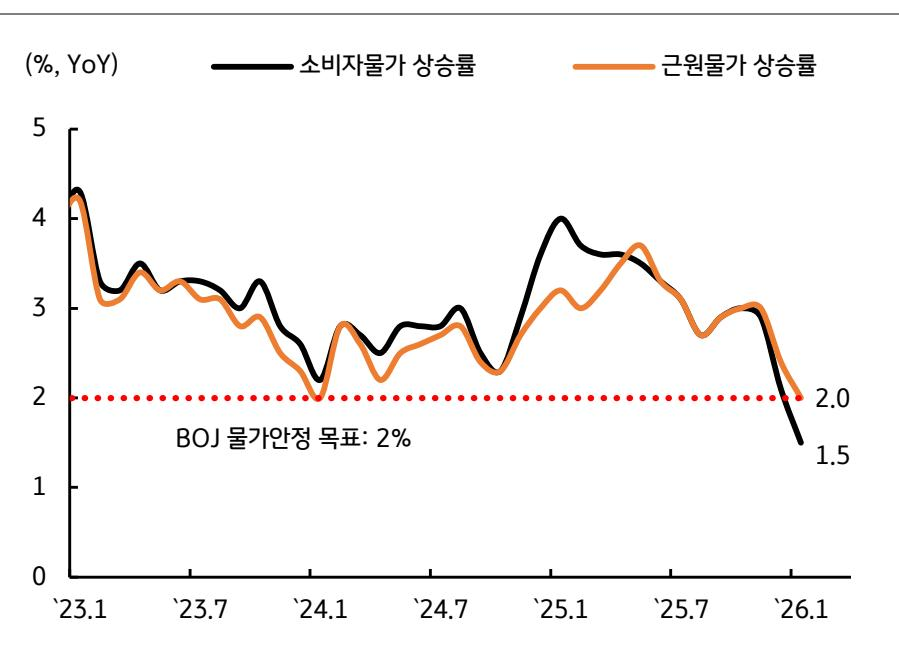
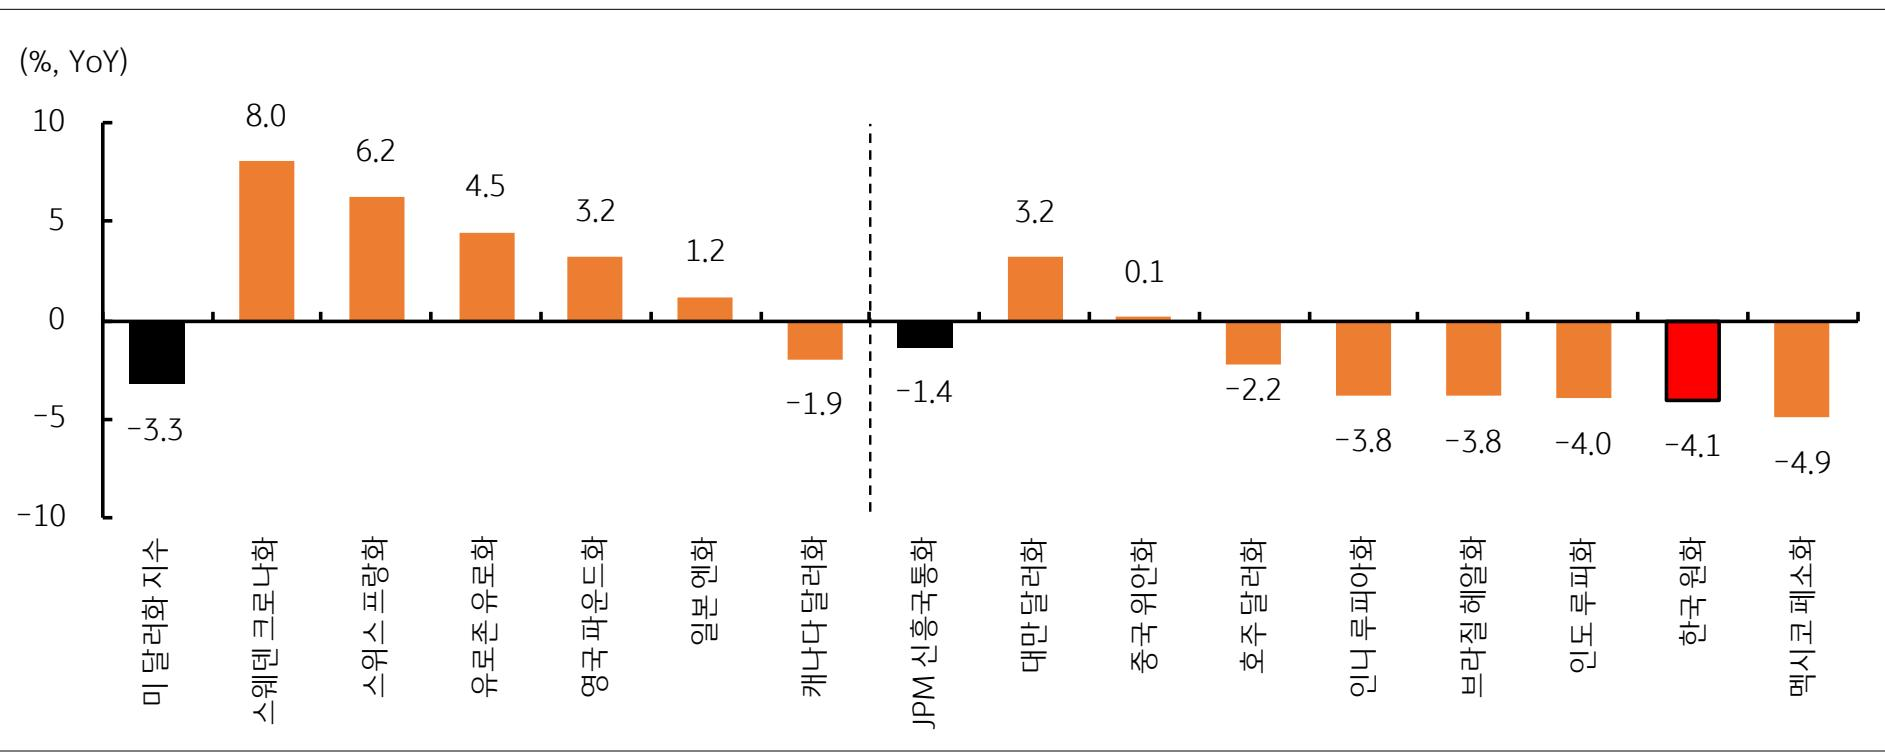

In [35]:
# 현재 디렉토리 파일 목록
file_path = [image_path + '/' + file_name for file_name in all_files]

# 'figure-16'로 시작하고 '.jpg'로 끝나는 파일만 선택
matched_files = [file for file in file_path if 'figure-3' in file and file.endswith('.jpg')]

# 이미지들을 base64로 인코딩하고 HTML로 묶기
html = "<div style='display: flex; flex-wrap: wrap;'>"
for file_name in matched_files:
    with open(file_name, "rb") as img_file:
        b64_img = base64.b64encode(img_file.read()).decode('utf-8')
    # object-fit: contain 추가!
    html += f"""
    <div style="flex: none; max-width: 200px; margin-right: 10px; margin-bottom: 10px;">
        <img src="data:image/jpeg;base64,{b64_img}" style="width: 100%; height: auto; display: block; object-fit: contain;">
    </div>
    """
html += "</div>"

display(HTML(html))